# Paleo Waifu — Meta Simulation Explorer

Interactive notebook for running the genetic algorithm meta simulation with different settings and exploring the results.

The meta sim evolves a population of 3v3 teams over multiple generations using:
- **Swiss pairing** (strength-matched opponents)
- **Both-sides play** (each matchup runs twice with sides swapped)
- **Formation evolution** (row assignments mutate alongside creature selection)
- **Diversity pressure** (rejects duplicate genomes in reproduction)

### Prerequisites
```bash
# From repo root — seed the local DB if not already done
cd python && uv run python scripts/generate_battle_seed.py
cd .. && pnpm db:seed:battle:local
```

In [ ]:
# ─── Reseed local DB ──────────────────────────────────────
# Re-generates battle_seed.sql from current constants and applies it to local D1.
# Run this cell after changing ROLE_DISTRIBUTIONS or ability templates in constants.ts.

import subprocess
from pathlib import Path

REPO_ROOT = Path('..').resolve()

print('Generating battle_seed.sql...')
gen = subprocess.run(
    ['uv', 'run', 'python', 'scripts/generate_battle_seed.py'],
    cwd=REPO_ROOT / 'python', capture_output=True, text=True
)
if gen.returncode != 0:
    print('FAILED:', gen.stderr)
    raise RuntimeError('generate_battle_seed.py failed')
print(gen.stdout)

print('Seeding local D1...')
seed = subprocess.run(
    ['pnpm', 'db:seed:battle:local'],
    cwd=REPO_ROOT, capture_output=True, text=True
)
if seed.returncode != 0:
    print('FAILED:', seed.stderr[:500])
    raise RuntimeError('db:seed:battle:local failed')

# Count successful commands from output
import re
match = re.search(r'(\d+) commands executed successfully', seed.stderr + seed.stdout)
if match:
    print(f'Seeded: {match.group(1)} commands executed successfully')
else:
    print('Seeded successfully')

Generating battle_seed.sql...
Reading from: /Users/jacobmaynard/Documents/Repos/paleo-waifu/.wrangler/state/v3/d1/miniflare-D1DatabaseObject/b04c5095b45a86ddff42da8364d11c28ceec1c12315f9484c93c031441fd8c63.sqlite
Found 40/40 roster creatures

Generated: /Users/jacobmaynard/Documents/Repos/paleo-waifu/battle_seed.sql
  Battle stats: 40
  Abilities: 80
  Roles: {'striker': 10, 'tank': 10, 'support': 10, 'bruiser': 10}
  Rarities: {'common': 17, 'uncommon': 12, 'rare': 8, 'epic': 3}
  Exported creature data: /Users/jacobmaynard/Documents/Repos/paleo-waifu/python/data/battle_creatures.json

Seeding local D1...
Seeded: 120 commands executed successfully


In [174]:
import subprocess
import io
import re
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

REPO_ROOT = Path('..').resolve()
SIM_DIR = REPO_ROOT / 'tools' / 'battle-sim'

ROLE_ORDER = ['striker', 'tank', 'support', 'bruiser']
RARITY_ORDER = ['common', 'uncommon', 'rare', 'epic', 'legendary']

ROLE_COLORS = {
    'striker': '#EF4444', 'tank': '#3B82F6',
    'support': '#EAB308', 'bruiser': '#A855F7',
}
RARITY_COLORS = {
    'common': '#9CA3AF', 'uncommon': '#22C55E', 'rare': '#06B6D4',
    'epic': '#A855F7', 'legendary': '#F59E0B',
}
FORMATION_COLORS = {
    '3F/0B': '#EF4444', '2F/1B': '#3B82F6', '1F/2B': '#22C55E', '0F/3B': '#9CA3AF',
}

# Target band for role share
ROLE_TARGET_LO = 15
ROLE_TARGET_HI = 35
TURNS_TARGET_LO = 7
TURNS_TARGET_HI = 10


# ─── Parse multi-section CSV ────────────────────────────────

def parse_meta_csv(csv_text: str) -> dict[str, pd.DataFrame]:
    """Parse the multi-section CSV output from `pnpm sim:meta --csv`."""
    sections: dict[str, list[list[str]]] = {}
    headers: dict[str, list[str]] = {}
    current_header: list[str] | None = None

    for line in csv_text.strip().split('\n'):
        if not line.strip():
            continue
        parts = [p.strip() for p in line.split(',')]

        if parts[0] == 'section':
            current_header = parts
            continue

        section_name = parts[0]
        if section_name not in sections:
            sections[section_name] = []
            if current_header:
                headers[section_name] = current_header

        sections[section_name].append(parts)

    dfs = {}
    for name, rows in sections.items():
        h = headers.get(name, [f'col{i}' for i in range(len(rows[0]))])
        df = pd.DataFrame(rows, columns=h)
        if 'section' in df.columns:
            df = df.drop(columns=['section'])
        for col in df.columns:
            try:
                df[col] = pd.to_numeric(df[col])
            except (ValueError, TypeError):
                pass
        dfs[name] = df

    return dfs


print('Ready.')

Ready.


---
## 1. Run the Meta Simulation

Configure parameters below and run. Results are captured and parsed automatically.

In [175]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SIMULATION PARAMETERS — edit these and re-run          ║
# ╚══════════════════════════════════════════════════════════╝

POPULATION = 200        # Number of teams per generation
GENERATIONS = 50        # Number of evolutionary generations
MATCHES_PER_TEAM = 30   # Swiss rounds per generation
NORMALIZE_STATS = True  # Scale all creatures to 170 total (rarity-neutral)
NO_ACTIVES = False      # Disable active abilities (all use Bite)
NO_PASSIVES = False     # Disable passive abilities
NUM_RUNS = 3            # Number of parallel runs to average

# Build CLI command
cmd = ['pnpm', 'sim:meta', '--csv']
cmd += ['--population', str(POPULATION)]
cmd += ['--generations', str(GENERATIONS)]
cmd += ['--matches', str(MATCHES_PER_TEAM)]
if NORMALIZE_STATS:
    cmd.append('--normalize-stats')
if NO_ACTIVES:
    cmd.append('--no-actives')
if NO_PASSIVES:
    cmd.append('--no-passives')

label = f'pop={POPULATION} gen={GENERATIONS} matches={MATCHES_PER_TEAM} ×{NUM_RUNS} runs'
if NORMALIZE_STATS: label += ' normalized'
if NO_ACTIVES: label += ' no-actives'
if NO_PASSIVES: label += ' no-passives'

print(f'Running {NUM_RUNS} sims in parallel: {" ".join(cmd)}')
print(f'Label: {label}')
print()

# Launch all runs in parallel using threads (subprocess.run releases the GIL)
def run_sim(run_id):
    result = subprocess.run(cmd, cwd=SIM_DIR, capture_output=True, text=True, timeout=600)
    return run_id, result

t0 = time.time()
all_results = []
with ThreadPoolExecutor(max_workers=NUM_RUNS) as executor:
    futures = {executor.submit(run_sim, i): i for i in range(NUM_RUNS)}
    for future in as_completed(futures):
        run_id, result = future.result()
        if result.returncode != 0:
            print(f'  Run {run_id + 1}: FAILED — {result.stderr[:200]}')
        else:
            all_results.append(result)
            print(f'  Run {run_id + 1}: done ({len(result.stdout)} bytes)')

elapsed = time.time() - t0
print(f'\nCompleted {len(all_results)}/{NUM_RUNS} runs in {elapsed:.1f}s')

if not all_results:
    raise RuntimeError('All simulation runs failed. Check the error messages above.')

# Parse all runs
all_data = [parse_meta_csv(r.stdout) for r in all_results]

# Use the first run as the base structure, then average numeric columns
raw_csv = all_results[0].stdout
data = all_data[0]

# Average metrics across runs
if len(all_data) > 1:
    role_dfs = [d.get('role_share', pd.DataFrame()) for d in all_data if 'role_share' in d]
    if role_dfs:
        combined = pd.concat(role_dfs)
        data['role_share'] = combined.groupby('role', as_index=False)['meta_share_pct'].mean()

    gen_dfs = [d.get('generation', pd.DataFrame()) for d in all_data if 'generation' in d]
    if gen_dfs:
        combined = pd.concat(gen_dfs)
        numeric_cols = combined.select_dtypes(include='number').columns.tolist()
        data['generation'] = combined.groupby('generation', as_index=False)[numeric_cols].mean()

    form_dfs = [d.get('formation_share', pd.DataFrame()) for d in all_data if 'formation_share' in d]
    if form_dfs:
        combined = pd.concat(form_dfs)
        data['formation_share'] = combined.groupby('formation', as_index=False)['meta_share_pct'].mean()

    syn_dfs = [d.get('synergy', pd.DataFrame()) for d in all_data if 'synergy' in d]
    if syn_dfs:
        combined = pd.concat(syn_dfs)
        data['synergy'] = combined.groupby('synergy', as_index=False)['meta_share_pct'].mean()

    abl_dfs = [d.get('ability', pd.DataFrame()) for d in all_data if 'ability' in d]
    if abl_dfs:
        combined = pd.concat(abl_dfs)
        data['ability'] = combined.groupby(['name', 'type'], as_index=False)['appearances'].mean().round(1)

    cre_dfs = [d.get('creature', pd.DataFrame()) for d in all_data if 'creature' in d]
    if cre_dfs:
        combined = pd.concat(cre_dfs)
        meta_cols = [c for c in combined.columns if c != 'appearances']
        data['creature'] = combined.groupby('name', as_index=False).agg(
            {**{c: 'first' for c in meta_cols if c != 'name'}, 'appearances': 'mean'}
        ).sort_values('appearances', ascending=False).head(30)
        data['creature']['appearances'] = data['creature']['appearances'].round(1)

    print(f'Averaged {len(all_data)} runs for all metrics')

Running 3 sims in parallel: pnpm sim:meta --csv --population 200 --generations 50 --matches 30 --normalize-stats
Label: pop=200 gen=50 matches=30 ×3 runs normalized

  Run 3: done (9653 bytes)
  Run 2: done (9558 bytes)
  Run 1: done (9611 bytes)

Completed 3/3 runs in 7.3s
Averaged 3 runs for all metrics


In [176]:
# ─── Extract dataframes ────────────────────────────────────

gen_df = data.get('generation', pd.DataFrame())
hof_df = data.get('hall_of_fame', pd.DataFrame())
role_df = data.get('role_share', pd.DataFrame())
form_df = data.get('formation_share', pd.DataFrame())
ability_df = data.get('ability', pd.DataFrame())
creature_df = data.get('creature', pd.DataFrame())
synergy_df = data.get('synergy', pd.DataFrame())

# Preview generation progression
if not gen_df.empty:
    display(gen_df.head(5))
    display(gen_df.tail(3))

,generation,top_fitness,avg_fitness,avg_turns,unique_genomes
0,1.0,76.110000,50.0,9.166667,200.0
1,2.0,72.220000,50.0,6.366667,200.0
2,3.0,71.110000,50.0,5.566667,200.0
3,4.0,68.333333,50.0,5.300000,200.0
4,5.0,69.996667,50.0,4.900000,200.0


,generation,top_fitness,avg_fitness,avg_turns,unique_genomes
47,48.0,70.000000,50.0,4.366667,200.0
48,49.0,69.443333,50.0,4.433333,200.0
49,50.0,68.890000,50.0,4.366667,200.0


---
## 2. Fitness Progression

How does the population evolve over generations? Look for:
- Steady convergence of top and average fitness
- Diversity declining gradually (not crashing to 0)
- Average turns in the 7-10 range

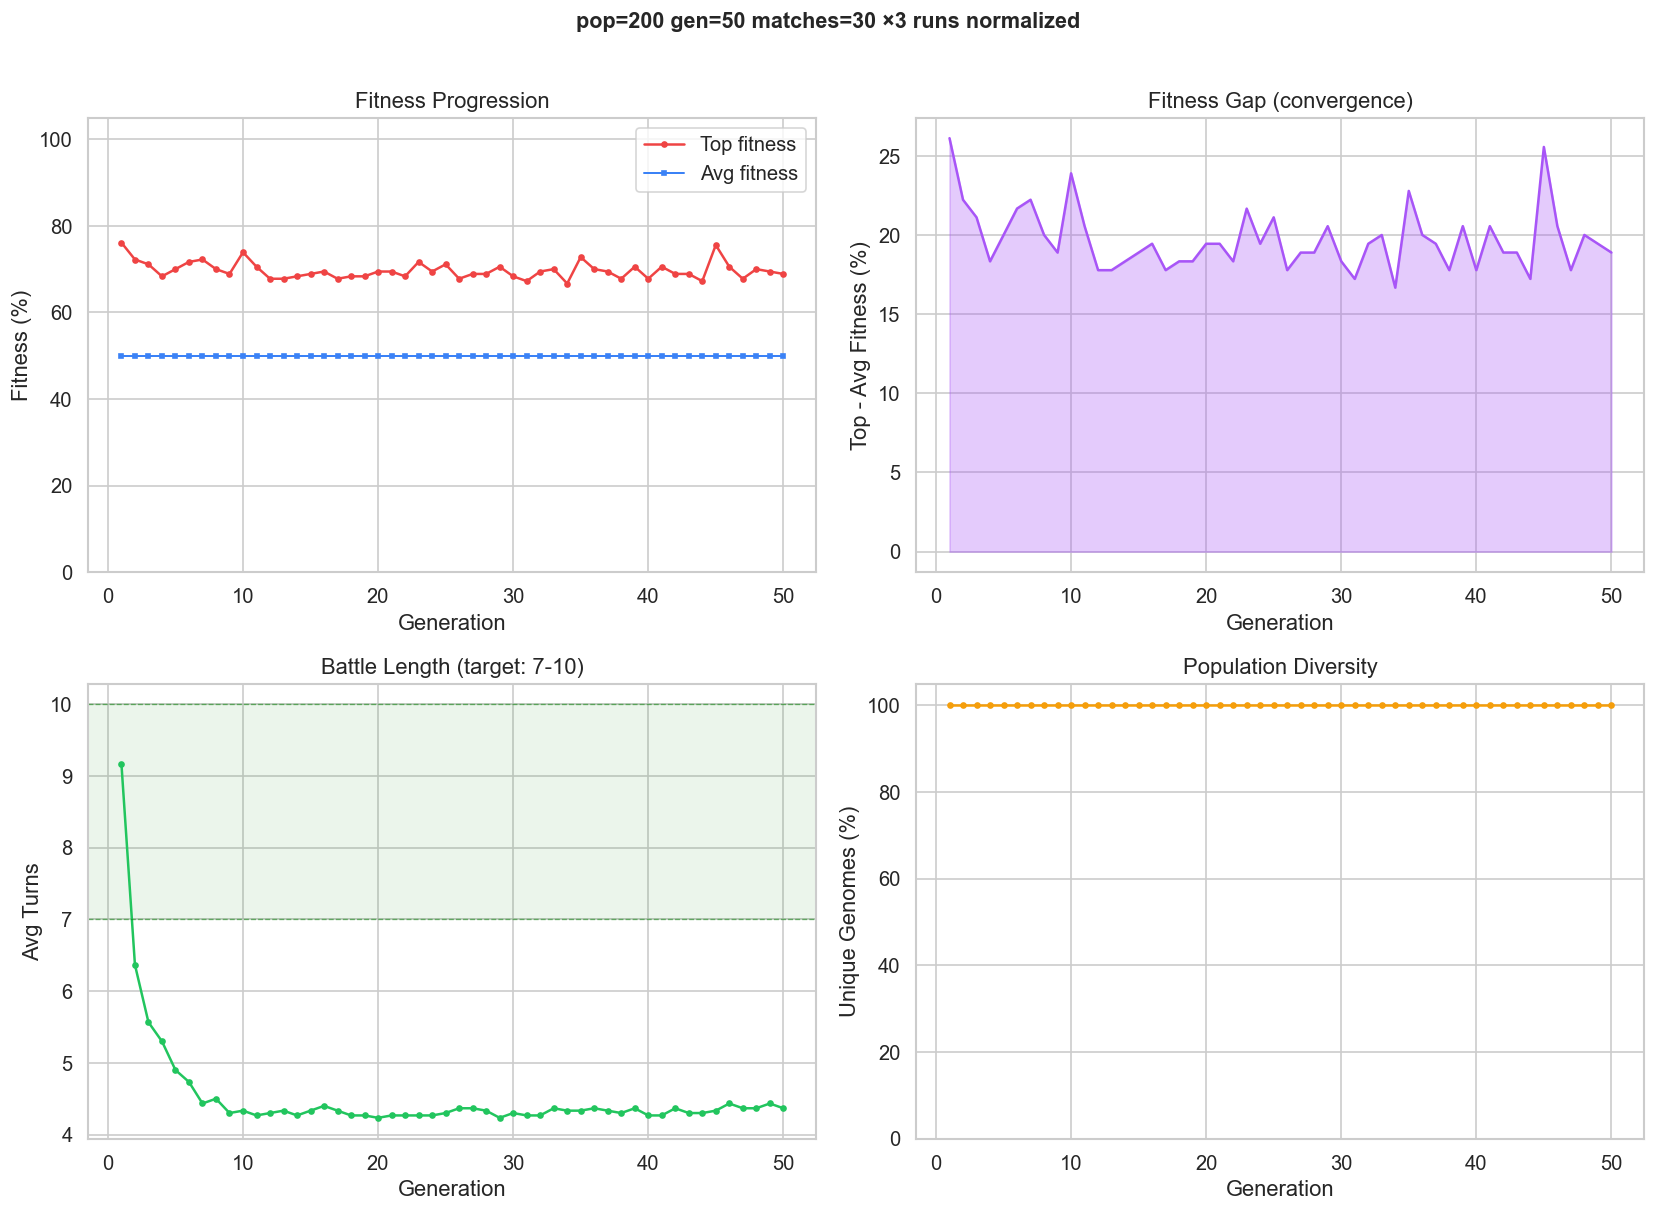

Final top fitness:  68.9% (started 76.1%)
Final avg fitness:  50.0% (started 50.0%)
Final avg turns:    4.4
Final diversity:    200.0/200 (100%)


In [177]:
if not gen_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Top & avg fitness
    ax = axes[0, 0]
    ax.plot(gen_df['generation'], gen_df['top_fitness'], 'o-', ms=3, lw=1.5, color='#EF4444', label='Top fitness')
    ax.plot(gen_df['generation'], gen_df['avg_fitness'], 's-', ms=2, lw=1.2, color='#3B82F6', label='Avg fitness')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (%)')
    ax.set_title('Fitness Progression')
    ax.legend()
    ax.set_ylim(0, 105)

    # Fitness gap (convergence indicator)
    ax = axes[0, 1]
    gap = gen_df['top_fitness'] - gen_df['avg_fitness']
    ax.fill_between(gen_df['generation'], 0, gap, alpha=0.3, color='#A855F7')
    ax.plot(gen_df['generation'], gap, '-', lw=1.5, color='#A855F7')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Top - Avg Fitness (%)')
    ax.set_title('Fitness Gap (convergence)')

    # Average turns
    ax = axes[1, 0]
    ax.plot(gen_df['generation'], gen_df['avg_turns'], 'o-', ms=3, lw=1.5, color='#22C55E')
    ax.axhspan(TURNS_TARGET_LO, TURNS_TARGET_HI, color='green', alpha=0.08)
    ax.axhline(TURNS_TARGET_LO, color='green', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(TURNS_TARGET_HI, color='green', ls='--', lw=0.8, alpha=0.5)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Avg Turns')
    ax.set_title(f'Battle Length (target: {TURNS_TARGET_LO}-{TURNS_TARGET_HI})')

    # Diversity
    ax = axes[1, 1]
    diversity_pct = (gen_df['unique_genomes'] / POPULATION) * 100
    ax.plot(gen_df['generation'], diversity_pct, 'o-', ms=3, lw=1.5, color='#F59E0B')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Unique Genomes (%)')
    ax.set_title('Population Diversity')
    ax.set_ylim(0, 105)

    fig.suptitle(label, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary stats
    last = gen_df.iloc[-1]
    first = gen_df.iloc[0]
    print(f'Final top fitness:  {last["top_fitness"]:.1f}% (started {first["top_fitness"]:.1f}%)')
    print(f'Final avg fitness:  {last["avg_fitness"]:.1f}% (started {first["avg_fitness"]:.1f}%)')
    print(f'Final avg turns:    {last["avg_turns"]:.1f}')
    print(f'Final diversity:    {last["unique_genomes"]}/{POPULATION} ({diversity_pct.iloc[-1]:.0f}%)')
else:
    print('No generation data available.')

---
## 3. Role Meta Share

The main balance metric. All 4 roles should be within the 15-35% target band.

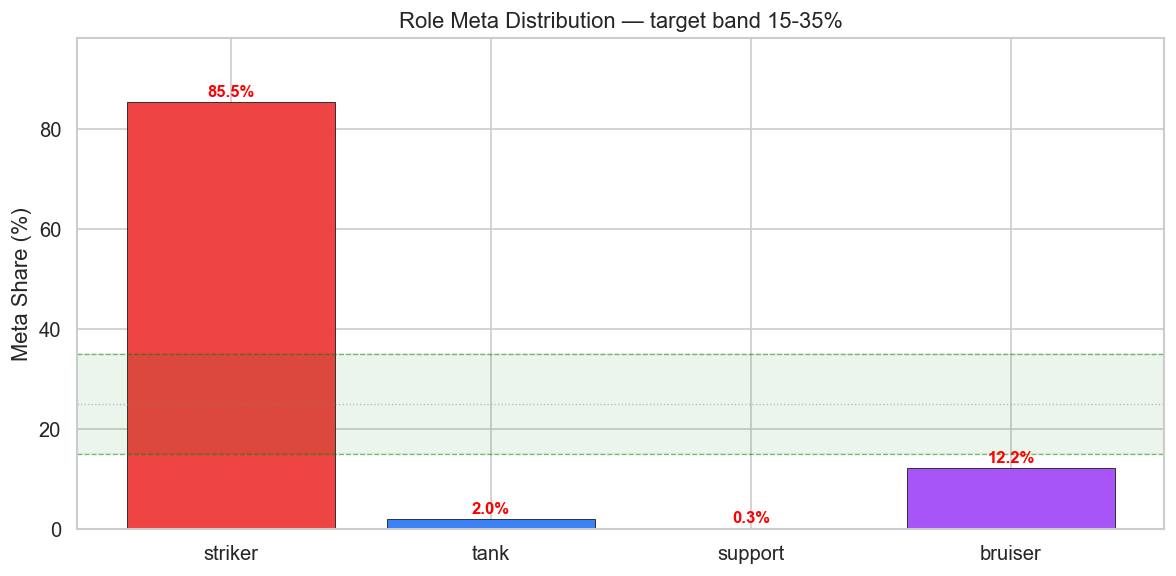

In [178]:
if not role_df.empty:
    role_df = role_df.copy()
    role_df['role'] = pd.Categorical(role_df['role'], categories=ROLE_ORDER, ordered=True)
    role_df = role_df.sort_values('role')

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [ROLE_COLORS.get(r, '#888') for r in role_df['role']]
    bars = ax.bar(role_df['role'].astype(str), role_df['meta_share_pct'], color=colors, edgecolor='k', linewidth=0.5)

    # Target band
    ax.axhspan(ROLE_TARGET_LO, ROLE_TARGET_HI, color='green', alpha=0.08)
    ax.axhline(ROLE_TARGET_LO, color='green', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(ROLE_TARGET_HI, color='green', ls='--', lw=0.8, alpha=0.5)
    # Ideal line (25% = 1/4)
    ax.axhline(100/4, color='gray', ls=':', lw=0.8, alpha=0.5)

    # Labels on bars
    for bar, val in zip(bars, role_df['meta_share_pct']):
        in_band = ROLE_TARGET_LO <= val <= ROLE_TARGET_HI
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10,
                fontweight='bold' if not in_band else 'normal',
                color='red' if not in_band else 'black')

    ax.set_ylabel('Meta Share (%)')
    ax.set_title(f'Role Meta Distribution — target band {ROLE_TARGET_LO}-{ROLE_TARGET_HI}%')
    ax.set_ylim(0, max(role_df['meta_share_pct'].max() * 1.15, ROLE_TARGET_HI * 1.5))
    plt.tight_layout()
    plt.show()

    # Flags
    for _, row in role_df.iterrows():
        share = row['meta_share_pct']
        if share > ROLE_TARGET_HI:
            print(f'  WARNING: {row["role"]} at {share:.1f}% — OVER target ({ROLE_TARGET_HI}%)')
        elif share < ROLE_TARGET_LO:
            print(f'  WARNING: {row["role"]} at {share:.1f}% — UNDER target ({ROLE_TARGET_LO}%)')
        else:
            print(f'  OK: {row["role"]} at {share:.1f}%')
else:
    print('No role share data.')

---
## 4. Formation Distribution

How many front vs back row creatures do winning teams prefer?

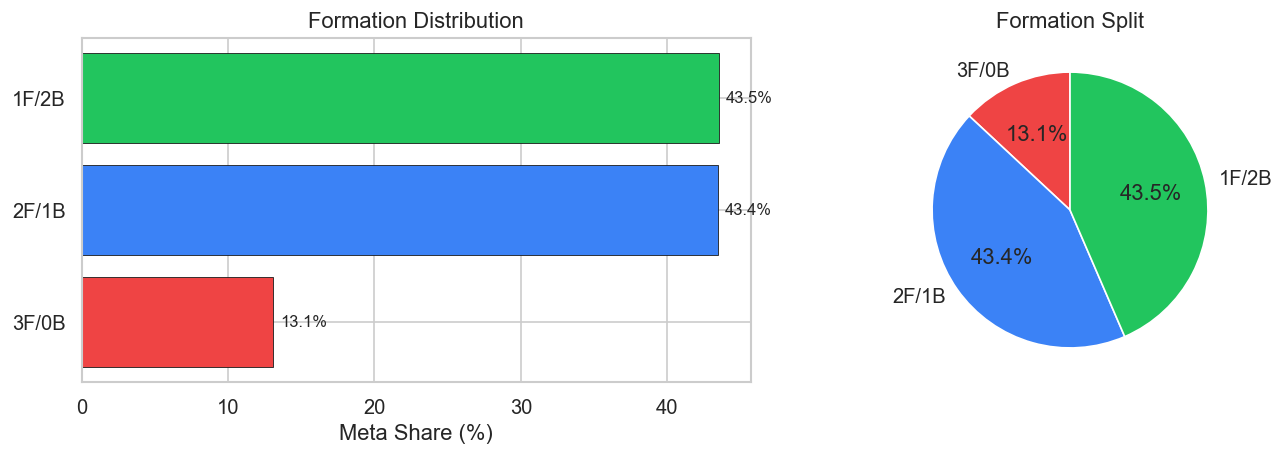

In [179]:
if not form_df.empty:
    form_df = form_df.sort_values('meta_share_pct', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    ax = axes[0]
    colors = [FORMATION_COLORS.get(f, '#888') for f in form_df['formation']]
    ax.barh(form_df['formation'], form_df['meta_share_pct'], color=colors, edgecolor='k', linewidth=0.5)
    for i, (_, row) in enumerate(form_df.iterrows()):
        ax.text(row['meta_share_pct'] + 0.5, i, f'{row["meta_share_pct"]:.1f}%', va='center', fontsize=10)
    ax.set_xlabel('Meta Share (%)')
    ax.set_title('Formation Distribution')

    # Pie chart
    ax = axes[1]
    pie_colors = [FORMATION_COLORS.get(f, '#888') for f in form_df['formation']]
    ax.pie(form_df['meta_share_pct'], labels=form_df['formation'], colors=pie_colors,
           autopct='%1.1f%%', startangle=90)
    ax.set_title('Formation Split')

    plt.tight_layout()
    plt.show()
else:
    print('No formation data.')

---
## 5. Hall of Fame

The top 10 all-time best teams discovered by the genetic algorithm.

In [180]:
if not hof_df.empty:
    display_df = hof_df[['rank', 'member1', 'member2', 'member3',
                         'rarity1', 'rarity2', 'rarity3',
                         'row1', 'row2', 'row3', 'peak_fitness']].copy()
    display_df['formation'] = display_df.apply(
        lambda r: '/'.join('F' if r[f'row{i}'] == 'front' else 'B' for i in [1,2,3]), axis=1
    )
    display_df['peak_fitness'] = display_df['peak_fitness'].apply(lambda x: f'{x:.1f}%')
    print('HALL OF FAME')
    display(display_df[['rank', 'member1', 'member2', 'member3', 'formation', 'peak_fitness']])

    # Rarity distribution in HoF
    rarities = pd.concat([
        hof_df['rarity1'], hof_df['rarity2'], hof_df['rarity3']
    ]).value_counts()
    print(f'\nRarity breakdown in HoF: {dict(rarities)}')
else:
    print('No hall of fame data.')

HALL OF FAME


,rank,member1,member2,member3,formation,peak_fitness
0,1,Coelophysis,Carnotaurus,Compsognathus,B/F/F,76.7%
1,2,Coelophysis,Baryonyx,Carnotaurus,F/B/B,75.0%
2,3,Richardoestesia,Carnotaurus,Compsognathus,F/B/B,73.3%
3,4,Coelophysis,Carnotaurus,Compsognathus,B/F/B,73.3%
4,5,Achillobator,Baryonyx,Carnotaurus,F/B/F,73.3%
5,6,Coelophysis,Baryonyx,Carnotaurus,F/F/F,73.3%
6,7,Achillobator,Coelophysis,Baryonyx,B/F/B,71.7%
7,8,Achillobator,Baryonyx,Carnotaurus,B/B/F,71.7%
8,9,Achillobator,Baryonyx,Carnotaurus,B/F/B,71.7%
9,10,Achillobator,Coelophysis,Carnotaurus,F/F/B,70.0%



Rarity breakdown in HoF: {'common': np.int64(11), 'epic': np.int64(9), 'uncommon': np.int64(6), 'rare': np.int64(4)}


---
## 6. Creature Leaderboard

Which individual creatures appear most often in top-quartile teams?

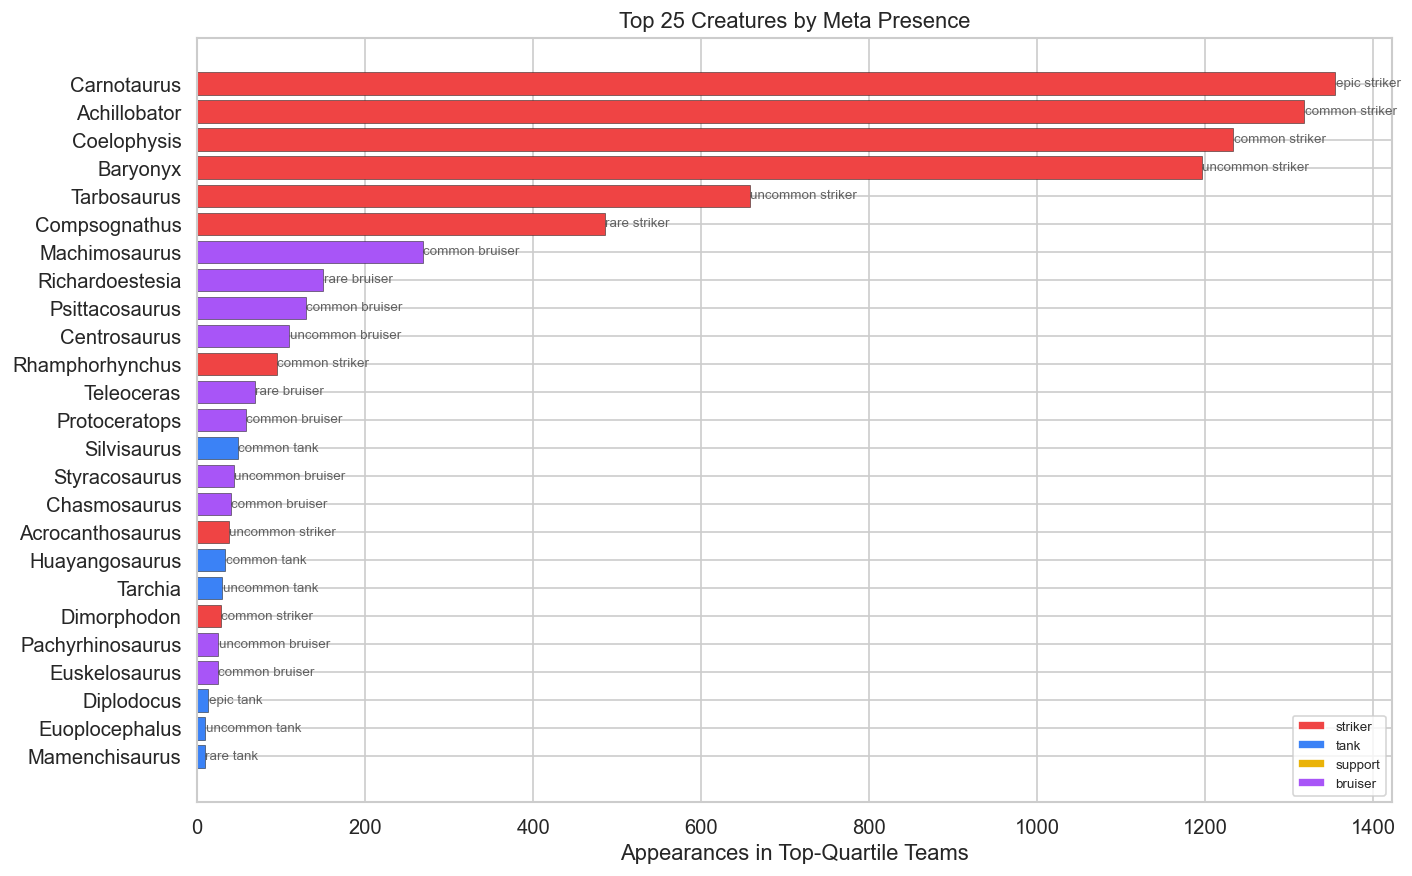

Role breakdown in top 25 creatures:
  striker: 9
  tank: 6
  support: 0
  bruiser: 10


In [181]:
if not creature_df.empty:
    top_n = min(25, len(creature_df))
    top_creatures = creature_df.head(top_n).copy()

    fig, ax = plt.subplots(figsize=(12, max(5, top_n * 0.3)))
    top_creatures = top_creatures.sort_values('appearances', ascending=True)
    colors = [ROLE_COLORS.get(r, '#888') for r in top_creatures['role']]
    ax.barh(top_creatures['name'], top_creatures['appearances'], color=colors, edgecolor='k', linewidth=0.3)

    # Annotate with rarity
    for i, (_, row) in enumerate(top_creatures.iterrows()):
        ax.text(row['appearances'] + 0.5, i,
                f'{row["rarity"]} {row["role"]}',
                va='center', fontsize=8, alpha=0.7)

    ax.set_xlabel('Appearances in Top-Quartile Teams')
    ax.set_title(f'Top {top_n} Creatures by Meta Presence')

    # Legend
    legend_items = [Patch(facecolor=c, label=r) for r, c in ROLE_COLORS.items()]
    ax.legend(handles=legend_items, loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

    # Role breakdown of top creatures
    role_counts = top_creatures['role'].value_counts()
    print(f'Role breakdown in top {top_n} creatures:')
    for r in ROLE_ORDER:
        print(f'  {r}: {role_counts.get(r, 0)}')
else:
    print('No creature data.')

---
## 7. Ability Leaderboard

Which abilities dominate the meta?

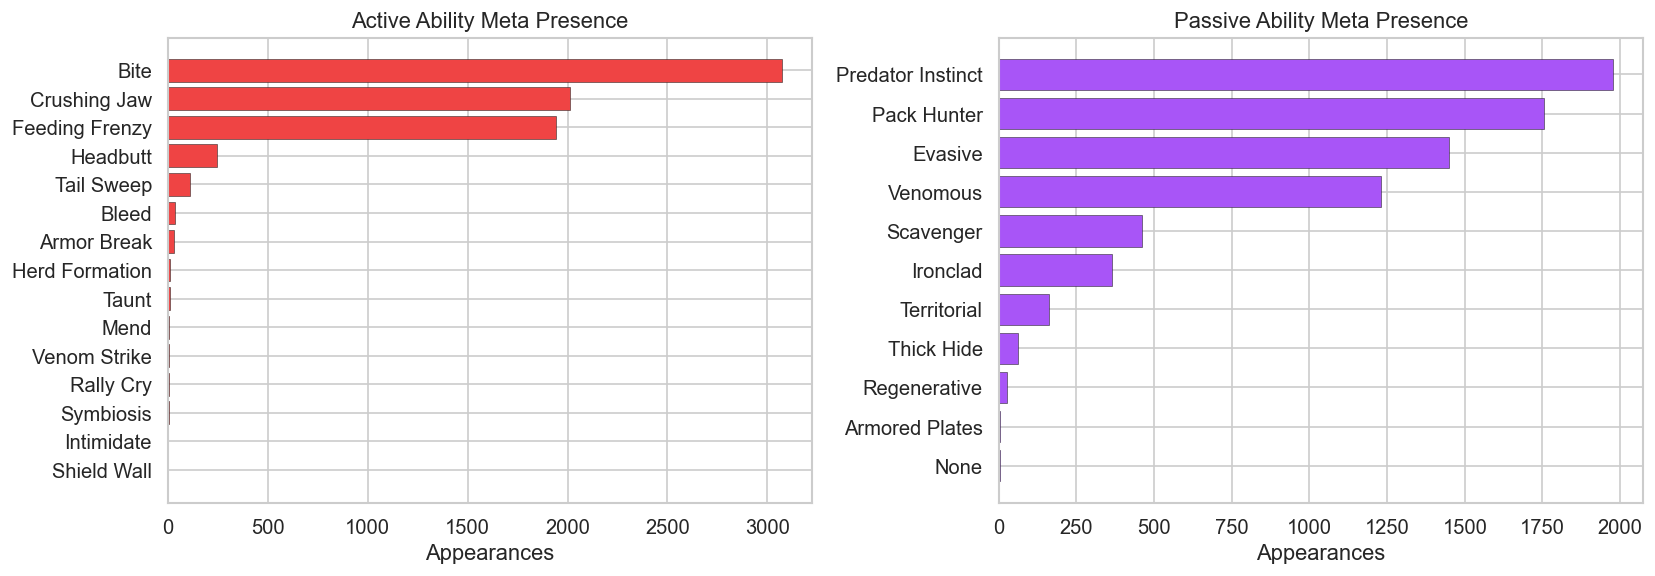

In [182]:
if not ability_df.empty:
    actives = ability_df[ability_df['type'] == 'active'].copy()
    passives = ability_df[ability_df['type'] == 'passive'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, max(len(actives), len(passives)) * 0.3)))

    # Active abilities
    ax = axes[0]
    if not actives.empty:
        actives = actives.sort_values('appearances', ascending=True)
        ax.barh(actives['name'], actives['appearances'], color='#EF4444', edgecolor='k', linewidth=0.3)
        ax.set_xlabel('Appearances')
        ax.set_title('Active Ability Meta Presence')

    # Passive abilities
    ax = axes[1]
    if not passives.empty:
        passives = passives.sort_values('appearances', ascending=True)
        ax.barh(passives['name'], passives['appearances'], color='#A855F7', edgecolor='k', linewidth=0.3)
        ax.set_xlabel('Appearances')
        ax.set_title('Passive Ability Meta Presence')

    plt.tight_layout()
    plt.show()
else:
    print('No ability data.')

---
## 8. Synergy Presence

How often do top teams leverage type/era/diet synergies?

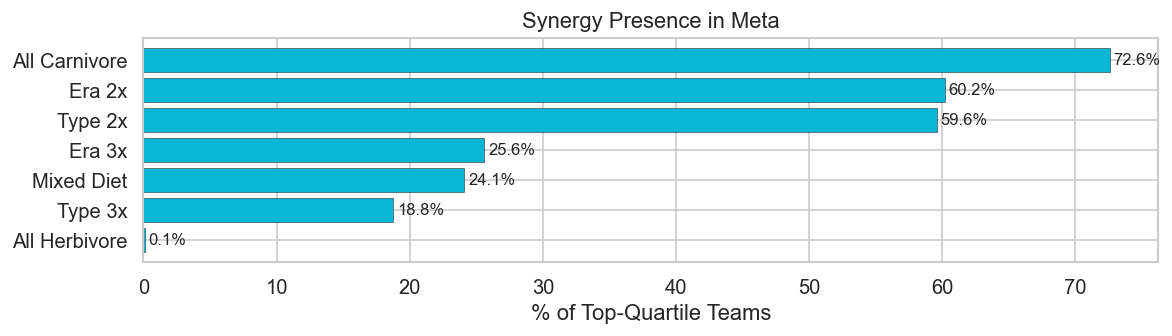

In [183]:
if not synergy_df.empty:
    synergy_df = synergy_df.sort_values('meta_share_pct', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(3, len(synergy_df) * 0.4)))
    ax.barh(synergy_df['synergy'], synergy_df['meta_share_pct'],
            color='#06B6D4', edgecolor='k', linewidth=0.3)
    for i, (_, row) in enumerate(synergy_df.iterrows()):
        ax.text(row['meta_share_pct'] + 0.3, i, f'{row["meta_share_pct"]:.1f}%',
                va='center', fontsize=10)
    ax.set_xlabel('% of Top-Quartile Teams')
    ax.set_title('Synergy Presence in Meta')
    plt.tight_layout()
    plt.show()
else:
    print('No synergy data.')

---
## 9. Multi-Run Comparison

Run multiple simulations with different settings and compare them side-by-side.

In [102]:
# ─── Run multiple configurations ──────────────────────────────

CONFIGS = [
    {'label': 'Full (all abilities)',   'normalize': True, 'no_actives': False, 'no_passives': False},
    {'label': 'No actives',             'normalize': True, 'no_actives': True,  'no_passives': False},
    {'label': 'No passives',            'normalize': True, 'no_actives': False, 'no_passives': True},
    {'label': 'Pure stats (no abilities)', 'normalize': True, 'no_actives': True,  'no_passives': True},
]

# Shared params for comparison runs (smaller for speed)
COMPARE_POP = 150
COMPARE_GEN = 30
COMPARE_MATCHES = 20

runs: dict[str, dict[str, pd.DataFrame]] = {}

for cfg in CONFIGS:
    cmd = ['pnpm', 'sim:meta', '--csv',
           '--population', str(COMPARE_POP),
           '--generations', str(COMPARE_GEN),
           '--matches', str(COMPARE_MATCHES)]
    if cfg['normalize']: cmd.append('--normalize-stats')
    if cfg['no_actives']: cmd.append('--no-actives')
    if cfg['no_passives']: cmd.append('--no-passives')

    print(f'Running: {cfg["label"]}...', end=' ', flush=True)
    res = subprocess.run(cmd, cwd=SIM_DIR, capture_output=True, text=True, timeout=600)
    if res.returncode != 0:
        print(f'FAILED: {res.stderr[:200]}')
        continue
    runs[cfg['label']] = parse_meta_csv(res.stdout)
    print('done')

print(f'\nCompleted {len(runs)} / {len(CONFIGS)} runs')

Running: Full (all abilities)... done
Running: No actives... done
Running: No passives... done
Running: Pure stats (no abilities)... done

Completed 4 / 4 runs


In [ ]:
# ─── Compare role distributions across runs ──────────────────

if runs:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(ROLE_ORDER))
    width = 0.8 / len(runs)
    run_colors = ['#EF4444', '#3B82F6', '#22C55E', '#F59E0B', '#A855F7']

    for i, (run_label, run_data) in enumerate(runs.items()):
        rdf = run_data.get('role_share', pd.DataFrame())
        if rdf.empty:
            continue
        shares = []
        for role in ROLE_ORDER:
            match = rdf[rdf['role'] == role]
            shares.append(match['meta_share_pct'].iloc[0] if not match.empty else 0)
        ax.bar(x + i * width, shares, width, label=run_label,
               color=run_colors[i % len(run_colors)], alpha=0.8, edgecolor='k', linewidth=0.3)

    # Target band
    ax.axhspan(ROLE_TARGET_LO, ROLE_TARGET_HI, color='green', alpha=0.06)
    ax.axhline(ROLE_TARGET_LO, color='green', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(ROLE_TARGET_HI, color='green', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(100/4, color='gray', ls=':', lw=0.8, alpha=0.4)

    ax.set_xticks(x + width * (len(runs) - 1) / 2)
    ax.set_xticklabels(ROLE_ORDER)
    ax.set_ylabel('Meta Share (%)')
    ax.set_title('Role Meta Share — Multi-Run Comparison')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
# ─── Compare fitness & turns across runs ────────────────────

if runs:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    run_colors = ['#EF4444', '#3B82F6', '#22C55E', '#F59E0B', '#A855F7']

    for i, (run_label, run_data) in enumerate(runs.items()):
        gdf = run_data.get('generation', pd.DataFrame())
        if gdf.empty:
            continue
        c = run_colors[i % len(run_colors)]

        # Top fitness
        axes[0].plot(gdf['generation'], gdf['top_fitness'], '-', lw=1.5, color=c, label=run_label)
        # Avg turns
        axes[1].plot(gdf['generation'], gdf['avg_turns'], '-', lw=1.5, color=c, label=run_label)
        # Diversity
        div = (gdf['unique_genomes'] / COMPARE_POP) * 100
        axes[2].plot(gdf['generation'], div, '-', lw=1.5, color=c, label=run_label)

    axes[0].set_title('Top Fitness')
    axes[0].set_ylabel('Fitness (%)')
    axes[0].legend(fontsize=8)

    axes[1].set_title('Avg Battle Length')
    axes[1].set_ylabel('Turns')
    axes[1].axhspan(TURNS_TARGET_LO, TURNS_TARGET_HI, color='green', alpha=0.08)
    axes[1].legend(fontsize=8)

    axes[2].set_title('Population Diversity')
    axes[2].set_ylabel('Unique Genomes (%)')
    axes[2].set_ylim(0, 105)
    axes[2].legend(fontsize=8)

    for ax in axes:
        ax.set_xlabel('Generation')

    plt.tight_layout()
    plt.show()

In [ ]:
# ─── Summary comparison table ──────────────────────────────

if runs:
    summary_rows = []
    for run_label, run_data in runs.items():
        row = {'Config': run_label}
        gdf = run_data.get('generation', pd.DataFrame())
        rdf = run_data.get('role_share', pd.DataFrame())

        if not gdf.empty:
            last = gdf.iloc[-1]
            row['Top Fit'] = f'{last["top_fitness"]:.1f}%'
            row['Avg Fit'] = f'{last["avg_fitness"]:.1f}%'
            row['Avg Turns'] = f'{last["avg_turns"]:.1f}'
            row['Diversity'] = f'{last["unique_genomes"]}/{COMPARE_POP}'

        if not rdf.empty:
            for role in ROLE_ORDER:
                match = rdf[rdf['role'] == role]
                share = match['meta_share_pct'].iloc[0] if not match.empty else 0
                row[role] = f'{share:.1f}%'

        summary_rows.append(row)

    summary = pd.DataFrame(summary_rows)
    print('MULTI-RUN COMPARISON')
    display(summary)

---
## 10. Diagnostic: Stat vs Ability Impact

If pure stats (no abilities) already show a dominant role, the problem is in stat distributions, not ability tuning.

In [ ]:
if runs:
    # Build diagnostic table
    diag_rows = []
    for run_label, run_data in runs.items():
        gdf = run_data.get('generation', pd.DataFrame())
        rdf = run_data.get('role_share', pd.DataFrame())
        if gdf.empty or rdf.empty:
            continue

        avg_turns = gdf['avg_turns'].mean()
        dominant = rdf.loc[rdf['meta_share_pct'].idxmax()]

        diag_rows.append({
            'Scenario': run_label,
            'Avg Turns': f'{avg_turns:.1f}',
            **{role: f'{rdf[rdf["role"]==role]["meta_share_pct"].iloc[0]:.1f}%'
               if not rdf[rdf["role"]==role].empty else '—'
               for role in ROLE_ORDER},
            'Dominant': f'{dominant["role"]} ({dominant["meta_share_pct"]:.1f}%)',
        })

    diag = pd.DataFrame(diag_rows)
    print('DIAGNOSTIC: Stat vs Ability Impact')
    print('If "Pure stats" already shows a dominant role, fix stats first.\n')
    display(diag)

    # Check if pure stats run exists and has a dominant role
    pure_label = 'Pure stats (no abilities)'
    if pure_label in runs:
        pure_rdf = runs[pure_label].get('role_share', pd.DataFrame())
        if not pure_rdf.empty:
            max_share = pure_rdf['meta_share_pct'].max()
            dom_role = pure_rdf.loc[pure_rdf['meta_share_pct'].idxmax(), 'role']
            if max_share > ROLE_TARGET_HI:
                print(f'\n  DIAGNOSIS: {dom_role} dominates even with pure stats ({max_share:.1f}%).')
                print(f'  -> Fix ROLE_DISTRIBUTIONS in constants.ts (reduce {dom_role} ATK/HP).')
            else:
                print(f'\n  DIAGNOSIS: Pure stats are balanced (max {max_share:.1f}%). Issues are ability-driven.')

---
## 11. Custom Run

Modify the parameters below to run a one-off experiment and see results inline.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CUSTOM RUN — change params and execute                 ║
# ╚══════════════════════════════════════════════════════════╝

CUSTOM_POP = 100
CUSTOM_GEN = 25
CUSTOM_MATCHES = 20
CUSTOM_NORMALIZE = True
CUSTOM_NO_ACTIVES = False
CUSTOM_NO_PASSIVES = False

cmd = ['pnpm', 'sim:meta', '--csv',
       '--population', str(CUSTOM_POP),
       '--generations', str(CUSTOM_GEN),
       '--matches', str(CUSTOM_MATCHES)]
if CUSTOM_NORMALIZE: cmd.append('--normalize-stats')
if CUSTOM_NO_ACTIVES: cmd.append('--no-actives')
if CUSTOM_NO_PASSIVES: cmd.append('--no-passives')

print(f'Running: {" ".join(cmd)}')
res = subprocess.run(cmd, cwd=SIM_DIR, capture_output=True, text=True, timeout=600)

if res.returncode != 0:
    print('FAILED:', res.stderr[:500])
else:
    custom_data = parse_meta_csv(res.stdout)
    custom_gen = custom_data.get('generation', pd.DataFrame())
    custom_role = custom_data.get('role_share', pd.DataFrame())

    if not custom_gen.empty and not custom_role.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Fitness
        ax = axes[0]
        ax.plot(custom_gen['generation'], custom_gen['top_fitness'], 'o-', ms=3, color='#EF4444', label='Top')
        ax.plot(custom_gen['generation'], custom_gen['avg_fitness'], 's-', ms=2, color='#3B82F6', label='Avg')
        ax.set_title('Fitness')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Fitness (%)')
        ax.legend()

        # Role share
        ax = axes[1]
        custom_role_sorted = custom_role.copy()
        custom_role_sorted['role'] = pd.Categorical(custom_role_sorted['role'], categories=ROLE_ORDER, ordered=True)
        custom_role_sorted = custom_role_sorted.sort_values('role')
        colors = [ROLE_COLORS.get(r, '#888') for r in custom_role_sorted['role']]
        ax.bar(custom_role_sorted['role'].astype(str), custom_role_sorted['meta_share_pct'],
               color=colors, edgecolor='k', linewidth=0.5)
        ax.axhspan(ROLE_TARGET_LO, ROLE_TARGET_HI, color='green', alpha=0.08)
        ax.axhline(100/6, color='gray', ls=':', lw=0.8, alpha=0.4)
        ax.set_ylabel('Meta Share (%)')
        ax.set_title('Role Distribution')

        plt.suptitle(f'Custom Run: pop={CUSTOM_POP} gen={CUSTOM_GEN} matches={CUSTOM_MATCHES}',
                     fontweight='bold')
        plt.tight_layout()
        plt.show()

        last = custom_gen.iloc[-1]
        print(f'Final: top={last["top_fitness"]:.1f}% avg={last["avg_fitness"]:.1f}% turns={last["avg_turns"]:.1f}')
    print(res.stderr[-300:] if res.stderr else '')